
Task 1: Naïve Bayes Classifier — SMS Spam Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, classification_report)

import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_excel('/content/sms_spam_dataset.xlsx')

df = df.iloc[:, :2]

df.columns = ['label', 'message']

print(df.shape)
print(df.columns.tolist())
df.head()

(5572, 2)
['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


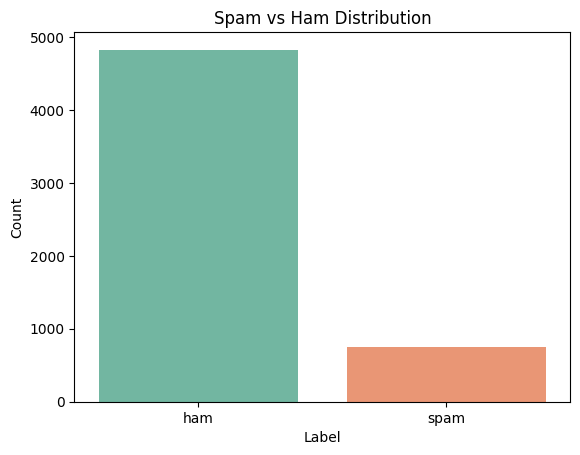

In [9]:
# Cell 3 — Exploratory Data Analysis
print("Class Distribution:")
print(df['label'].value_counts())

sns.countplot(x='label', data=df, palette='Set2')
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [12]:
# Cell 4 — FIXED Preprocessing
import re
import string

df = df.dropna(subset=['message'])

df['message'] = df['message'].astype(str)

def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = text.strip()
    return text

df['clean_message'] = df['message'].apply(preprocess_text)

# Encode labels: ham=0, spam=1
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

print("Preprocessing Done!")
print(df[['message', 'clean_message', 'label_enc']].head())

Preprocessing Done!
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  label_enc  
0  go until jurong point crazy available only in ...          0  
1                            ok lar joking wif u oni          0  
2  free entry in  a wkly comp to win fa cup final...          1  
3        u dun say so early hor u c already then say          0  
4  nah i dont think he goes to usf he lives aroun...          0  


In [13]:
# Cell 5 — Train/Test Split + Vectorization
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

X = df['clean_message']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Bag of Words
count_vect = CountVectorizer(stop_words='english')
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts  = count_vect.transform(X_test)

# TF-IDF
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_test_tfidf  = tfidf_transformer.transform(X_test_counts)

print("Training set size:", X_train_tfidf.shape)
print("Test set size    :", X_test_tfidf.shape)

Training set size: (4457, 7275)
Test set size    : (1115, 7275)


In [14]:
# Cell 6 — Train Naïve Bayes Model
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)

print("Model trained successfully!")
print(f"Total predictions made: {len(y_pred)}")

Model trained successfully!
Total predictions made: 1115


True Positive  (TP): 108
True Negative  (TN): 965
False Positive (FP): 1
False Negative (FN): 41


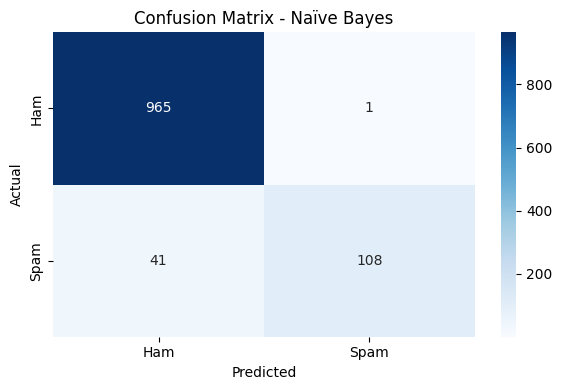

In [15]:
# Cell 7 — Confusion Matrix (TP, TN, FP, FN)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()
print(f"True Positive  (TP): {TP}")
print(f"True Negative  (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.title('Confusion Matrix - Naïve Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [16]:
# Cell 8 — Accuracy, Precision, Recall
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

Accuracy  : 0.9623  (96.23%)
Precision : 0.9908
Recall    : 0.7248

Detailed Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115

